# Методы Монте-Карло и цепи Маркова

## Модуль 4: Методы Монте-Карло, цепи Маркова, MCMC

В этом ноутбуке мы рассмотрим методы Монте-Карло и их применение в статистике.

### Содержание:
1. Основы метода Монте-Карло
2. Монте-Карло интегрирование
3. Цепи Маркова
4. MCMC (Markov Chain Monte Carlo)
5. Алгоритм Метрополиса-Гастингса

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Библиотеки успешно загружены!')

Библиотеки успешно загружены!


## 1. Основы метода Монте-Карло

**Метод Монте-Карло** — это класс алгоритмов, основанных на многократном случайном sampling.

### Основная идея:
Вместо точного вычисления сложных интегралов или сумм, мы аппроксимируем их с помощью случайных выборок.

### Применения:
- Численное интегрирование
- Оптимизация
- Моделирование физических процессов
- Байесовский вывод
- Финансовое моделирование

### Пример: Оценка числа $\pi$
Генерируем случайные точки в квадрате $[0,1] \times [0,1]$ и проверяем, попадают ли они в четверть круга.

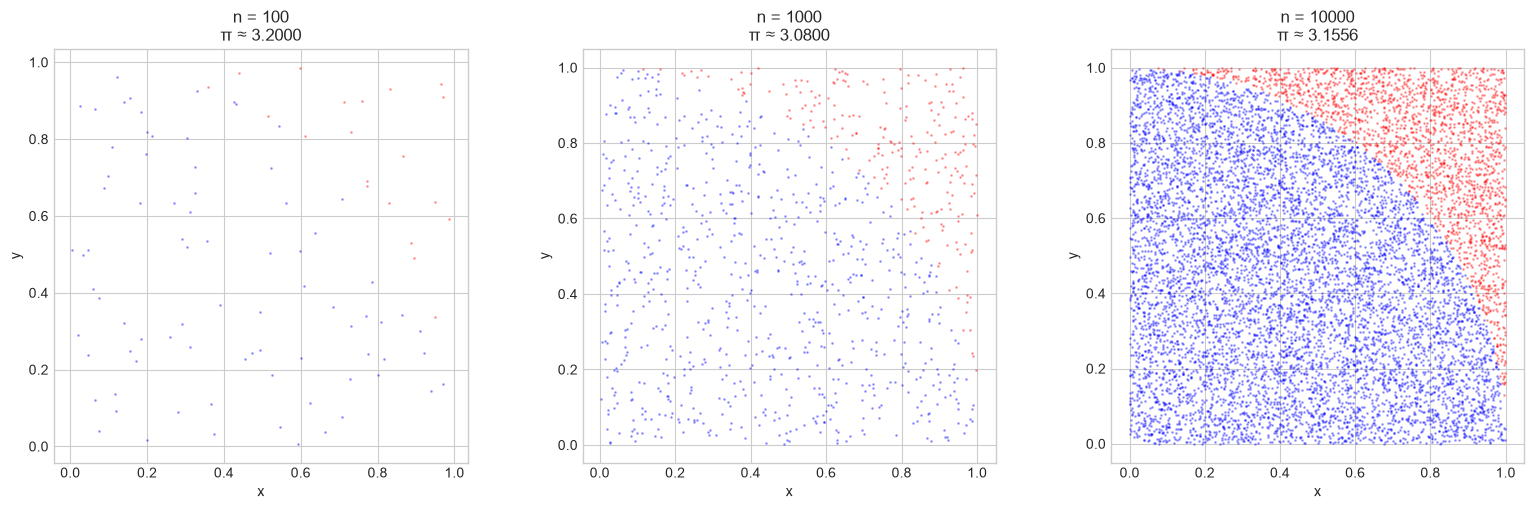

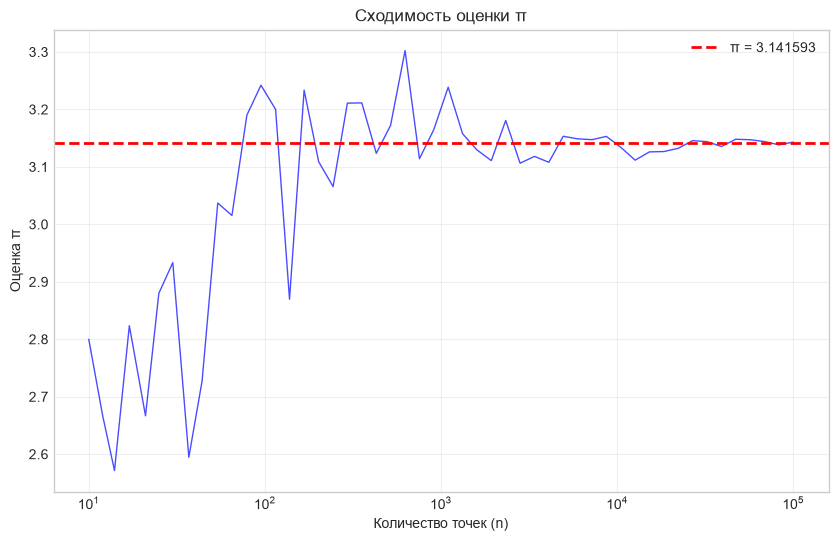

In [2]:
# Пример: Оценка числа π методом Монте-Карло
np.random.seed(42)

def estimate_pi(n_samples):
    """Оценка числа π методом Монте-Карло"""
    # Генерация случайных точек
    x = np.random.uniform(0, 1, n_samples)
    y = np.random.uniform(0, 1, n_samples)
    
    # Проверка попадания в четверть круга
    distances = x**2 + y**2
    inside_circle = distances <= 1
    
    # Оценка π
    pi_estimate = 4 * np.sum(inside_circle) / n_samples
    
    return pi_estimate, x, y, inside_circle

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

n_samples_list = [100, 1000, 10000]

for idx, n in enumerate(n_samples_list):
    pi_est, x, y, inside = estimate_pi(n)
    
    axes[idx].scatter(x[inside], y[inside], alpha=0.3, color='blue', s=1)
    axes[idx].scatter(x[~inside], y[~inside], alpha=0.3, color='red', s=1)
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(f'n = {n}\nπ ≈ {pi_est:.4f}')
    axes[idx].set_aspect('equal')

plt.tight_layout()
plt.show()

# Сходимость
n_range = np.logspace(1, 5, 50).astype(int)
pi_estimates = [estimate_pi(n)[0] for n in n_range]

plt.figure(figsize=(10, 6))
plt.plot(n_range, pi_estimates, 'b-', linewidth=1, alpha=0.7)
plt.axhline(np.pi, color='red', linestyle='--', linewidth=2, label=f'π = {np.pi:.6f}')
plt.xscale('log')
plt.xlabel('Количество точек (n)')
plt.ylabel('Оценка π')
plt.title('Сходимость оценки π')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2. Монте-Карло интегрирование

### Задача:
Вычислить интеграл:
$$I = \int_a^b f(x) dx$$

### Метод:
1. Генерируем $n$ случайных точек $x_i \sim U(a, b)$
2. Вычисляем среднее значение $f(x_i)$
3. Умножаем на длину интервала $(b-a)$

$$I \approx (b-a) \cdot \frac{1}{n} \sum_{i=1}^{n} f(x_i)$$

### Оценка ошибки:
$$\text{SE} = \frac{(b-a) \cdot s_f}{\sqrt{n}}$$

где $s_f$ — стандартное отклонение $f(x_i)$.

**Скорость сходимости:** $O(1/\sqrt{n})$ (не зависит от размерности!)

Монте-Карло интегрирование
∫₀^π sin(x)dx

Точное значение: 2.0
Оценка Монте-Карло: 2.007693
Стандартная ошибка: 0.009670
Относительная ошибка: 0.3846%


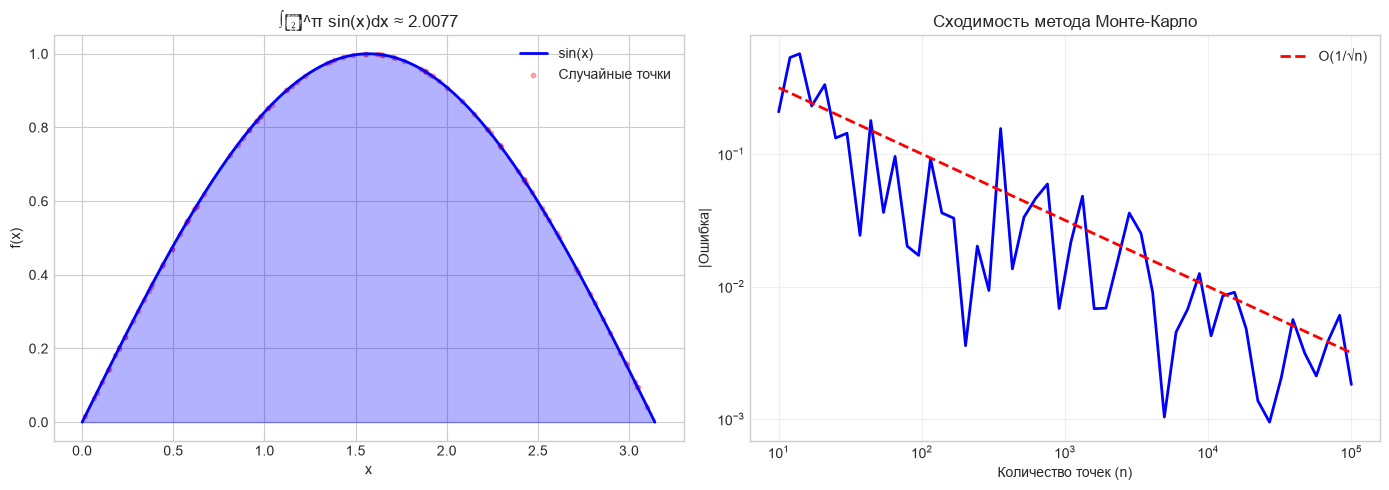

In [3]:
# Пример: Монте-Карло интегрирование
np.random.seed(42)

# Функция для интегрирования
def f(x):
    return np.sin(x)

# Точное значение интеграла ∫₀^π sin(x)dx = 2
exact_value = 2.0

# Монте-Карло интегрирование
a, b = 0, np.pi
n_samples = 10000

x_random = np.random.uniform(a, b, n_samples)
f_values = f(x_random)

integral_estimate = (b - a) * np.mean(f_values)
integral_std = (b - a) * np.std(f_values) / np.sqrt(n_samples)

print('Монте-Карло интегрирование')
print('=' * 60)
print(f'∫₀^π sin(x)dx')
print(f'\nТочное значение: {exact_value}')
print(f'Оценка Монте-Карло: {integral_estimate:.6f}')
print(f'Стандартная ошибка: {integral_std:.6f}')
print(f'Относительная ошибка: {abs(integral_estimate - exact_value)/exact_value*100:.4f}%')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Функция и точки
x_plot = np.linspace(a, b, 1000)
axes[0].plot(x_plot, f(x_plot), 'b-', linewidth=2, label='sin(x)')
axes[0].scatter(x_random[:100], f_values[:100], alpha=0.3, color='red', s=10, label='Случайные точки')
axes[0].fill_between(x_plot, f(x_plot), alpha=0.3, color='blue')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_title(f'∫₀^π sin(x)dx ≈ {integral_estimate:.4f}')
axes[0].legend()

# Сходимость
n_range = np.logspace(1, 5, 50).astype(int)
estimates = []
errors = []

for n in n_range:
    x = np.random.uniform(a, b, n)
    est = (b - a) * np.mean(f(x))
    estimates.append(est)
    errors.append(abs(est - exact_value))

axes[1].plot(n_range, errors, 'b-', linewidth=2)
axes[1].plot(n_range, 1/np.sqrt(n_range), 'r--', linewidth=2, label='O(1/√n)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Количество точек (n)')
axes[1].set_ylabel('|Ошибка|')
axes[1].set_title('Сходимость метода Монте-Карло')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Цепи Маркова

**Цепь Маркова** — это стохастический процесс, в котором будущее состояние зависит только от текущего состояния (свойство Маркова).

$$P(X_{n+1} | X_n, X_{n-1}, ..., X_0) = P(X_{n+1} | X_n)$$

### Матрица переходов:
$$P = \begin{pmatrix} p_{11} & p_{12} & \cdots & p_{1k} \\ p_{21} & p_{22} & \cdots & p_{2k} \\ \vdots & \vdots & \ddots & \vdots \\ p_{k1} & p_{k2} & \cdots & p_{kk} \end{pmatrix}$$

где $p_{ij} = P(X_{n+1} = j | X_n = i)$

### Стационарное распределение:
$$\pi P = \pi$$

где $\pi = (\pi_1, ..., \pi_k)$ — вектор стационарных вероятностей.

Матрица переходов:
          Солнечно  Облачно  Дождь
Солнечно       0.7      0.2    0.1
Облачно        0.3      0.4    0.3
Дождь          0.2      0.3    0.5

Стационарное распределение:
  Солнечно: 0.4565
  Облачно: 0.2826
  Дождь: 0.2609


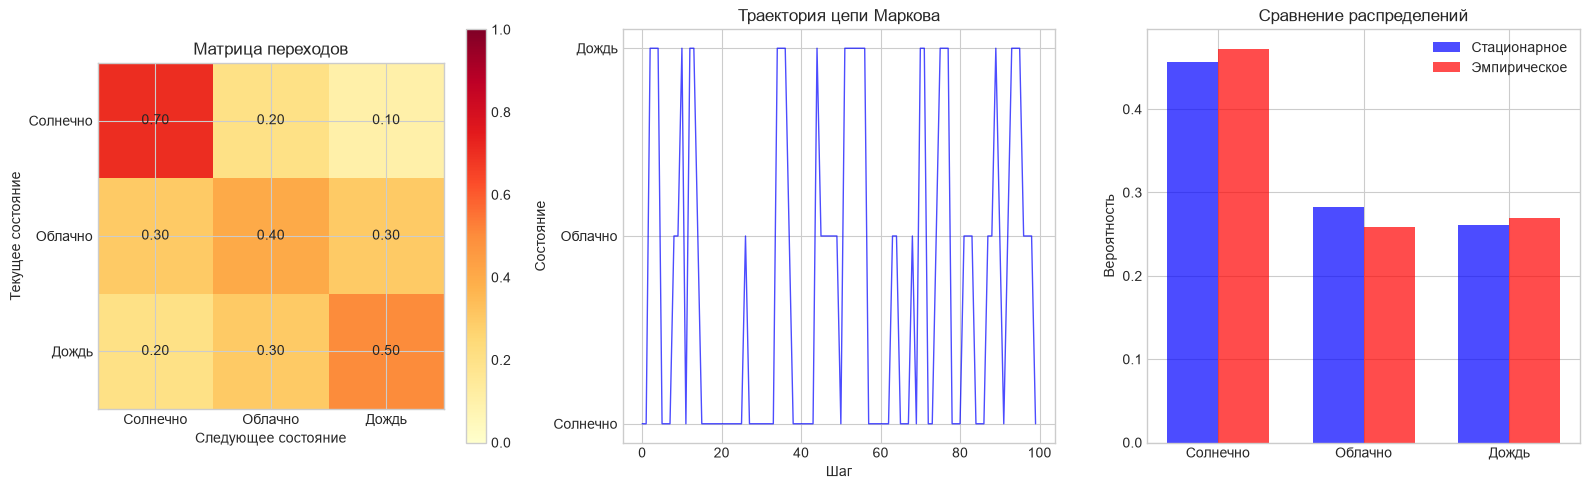

In [4]:
# Пример: Цепь Маркова — погода
np.random.seed(42)

# Состояния: 0 = Солнечно, 1 = Облачно, 2 = Дождь
states = ['Солнечно', 'Облачно', 'Дождь']
n_states = len(states)

# Матрица переходов
P = np.array([
    [0.7, 0.2, 0.1],  # Из Солнечно
    [0.3, 0.4, 0.3],  # Из Облачно
    [0.2, 0.3, 0.5]   # Из Дождь
])

print('Матрица переходов:')
print(pd.DataFrame(P, index=states, columns=states).round(2))

# Стационарное распределение
eigenvalues, eigenvectors = np.linalg.eig(P.T)
stationary = eigenvectors[:, np.argmax(np.isclose(eigenvalues, 1))].real
stationary = stationary / stationary.sum()

print(f'\nСтационарное распределение:')
for state, prob in zip(states, stationary):
    print(f'  {state}: {prob:.4f}')

# Симуляция цепи Маркова
n_steps = 1000
chain = [0]  # Начинаем с солнца

for _ in range(n_steps - 1):
    current_state = chain[-1]
    next_state = np.random.choice(n_states, p=P[current_state])
    chain.append(next_state)

chain = np.array(chain)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Матрица переходов
im = axes[0].imshow(P, cmap='YlOrRd', vmin=0, vmax=1)
axes[0].set_xticks(range(n_states))
axes[0].set_xticklabels(states)
axes[0].set_yticks(range(n_states))
axes[0].set_yticklabels(states)
axes[0].set_xlabel('Следующее состояние')
axes[0].set_ylabel('Текущее состояние')
axes[0].set_title('Матрица переходов')
plt.colorbar(im, ax=axes[0])

# Добавим значения
for i in range(n_states):
    for j in range(n_states):
        axes[0].text(j, i, f'{P[i, j]:.2f}', ha='center', va='center', fontsize=10)

# Траектория
axes[1].plot(chain[:100], 'b-', linewidth=1, alpha=0.7)
axes[1].set_yticks(range(n_states))
axes[1].set_yticklabels(states)
axes[1].set_xlabel('Шаг')
axes[1].set_ylabel('Состояние')
axes[1].set_title('Траектория цепи Маркова')

# Эмпирическое vs стационарное
empirical = np.array([np.mean(chain == i) for i in range(n_states)])
x = np.arange(n_states)
width = 0.35
axes[2].bar(x - width/2, stationary, width, label='Стационарное', color='blue', alpha=0.7)
axes[2].bar(x + width/2, empirical, width, label='Эмпирическое', color='red', alpha=0.7)
axes[2].set_xticks(x)
axes[2].set_xticklabels(states)
axes[2].set_ylabel('Вероятность')
axes[2].set_title('Сравнение распределений')
axes[2].legend()

plt.tight_layout()
plt.show()

## 4. MCMC (Markov Chain Monte Carlo)

**MCMC** — это методы для сэмплирования из сложных распределений.

### Задача:
Мы хотим сэмплировать из апостериорного распределения $P(\theta | \text{data})$, которое может быть неизвестной нормализующей константы.

### Идея:
Строим цепь Маркова, стационарное распределение которой совпадает с целевым распределением.

### Алгоритм Метрополиса-Гастингса:
1. Инициализация: $\theta_0$
2. Для $t = 1, 2, ...$:
   - Предложить новый кандидат: $\theta^* \sim q(\theta^* | \theta_t)$
   - Вычислить коэффициент принятия:
     $$\alpha = \min\left(1, \frac{P(\theta^* | \text{data}) \cdot q(\theta_t | \theta^*)}{P(\theta_t | \text{data}) \cdot q(\theta^* | \theta_t)}\right)$$
   - Принять $\theta^*$ с вероятностью $\alpha$:
     $$\theta_{t+1} = \begin{cases} \theta^* & \text{с вероятностью } \alpha \\ \theta_t & \text{иначе} \end{cases}$$

MCMC для байесовского вывода
Данные: 12 успехов из 20
Априорное: Beta(2, 2)
Апостериорное: Beta(14, 10)

MCMC: 10000 сэмплов, burn-in = 1000
Среднее MCMC: 0.5878
Среднее аналитическое: 0.5833


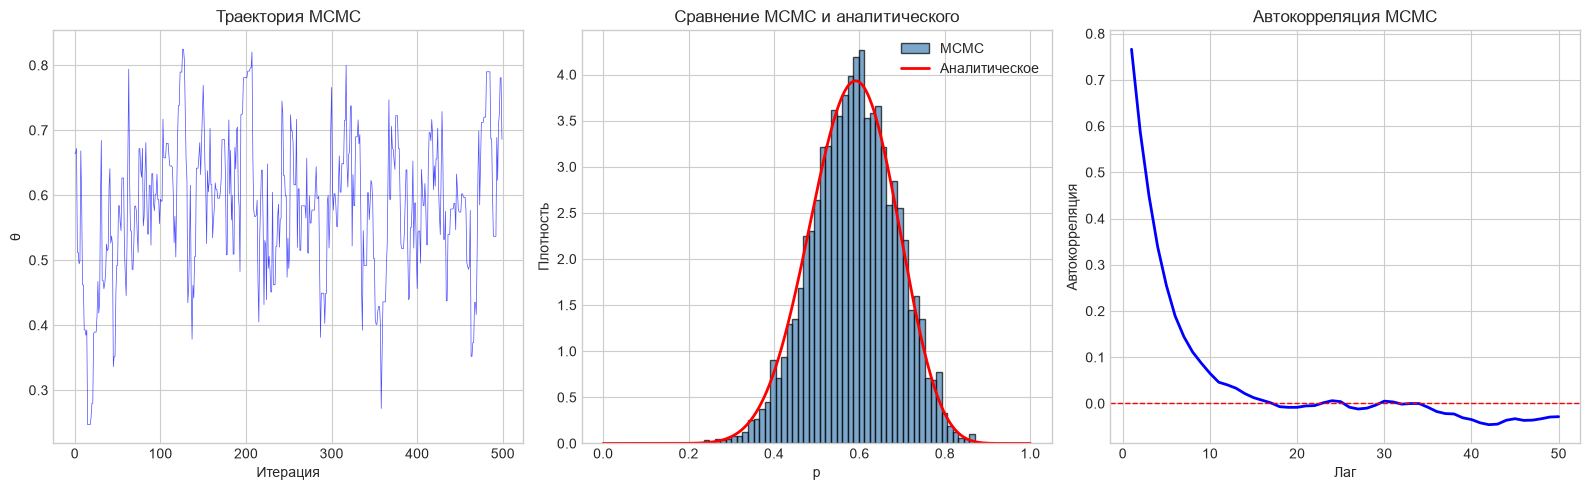

In [5]:
# Пример: MCMC для байесовского вывода
np.random.seed(42)

# Данные
n = 20
x = 12  # Количество успехов

# Априорное: Beta(2, 2)
alpha_prior = 2
beta_prior = 2

# Апостериорное (аналитическое): Beta(14, 10)
alpha_post = alpha_prior + x
beta_post = beta_prior + n - x

# MCMC: Алгоритм Метрополиса-Гастингса
def metropolis_hastings(n_samples, proposal_std=0.1):
    """MCMC для бета-распределения"""
    samples = []
    current = 0.5  # Начальное значение
    
    for _ in range(n_samples):
        # Предложить кандидата
        proposal = np.random.normal(current, proposal_std)
        
        # Проверить границы
        if proposal <= 0 or proposal >= 1:
            samples.append(current)
            continue
        
        # Вычислить отношение правдоподобия (упрощённо)
        # Используем апостериорное напрямую
        current_prob = stats.beta.pdf(current, alpha_post, beta_post)
        proposal_prob = stats.beta.pdf(proposal, alpha_post, beta_post)
        
        # Коэффициент принятия
        acceptance_ratio = proposal_prob / current_prob
        
        # Принять или отклонить
        if np.random.uniform() < acceptance_ratio:
            current = proposal
        
        samples.append(current)
    
    return np.array(samples)

# Запуск MCMC
n_samples = 10000
samples_mcmc = metropolis_hastings(n_samples, proposal_std=0.1)

# Отбрасываем "burn-in"
burn_in = 1000
samples_mcmc = samples_mcmc[burn_in:]

# Аналитическое апостериорное
p_range = np.linspace(0, 1, 1000)
analytical_posterior = stats.beta.pdf(p_range, alpha_post, beta_post)

print('MCMC для байесовского вывода')
print('=' * 60)
print(f'Данные: {x} успехов из {n}')
print(f'Априорное: Beta({alpha_prior}, {beta_prior})')
print(f'Апостериорное: Beta({alpha_post}, {beta_post})')
print(f'\nMCMC: {n_samples} сэмплов, burn-in = {burn_in}')
print(f'Среднее MCMC: {np.mean(samples_mcmc):.4f}')
print(f'Среднее аналитическое: {alpha_post/(alpha_post+beta_post):.4f}')

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Траектория
axes[0].plot(samples_mcmc[:500], 'b-', linewidth=0.5, alpha=0.7)
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('θ')
axes[0].set_title('Траектория MCMC')

# Гистограмма vs аналитическое
axes[1].hist(samples_mcmc, bins=50, density=True, alpha=0.7, color='steelblue', 
             edgecolor='black', label='MCMC')
axes[1].plot(p_range, analytical_posterior, 'r-', linewidth=2, label='Аналитическое')
axes[1].set_xlabel('p')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Сравнение MCMC и аналитического')
axes[1].legend()

# Автокорреляция
max_lag = 50
autocorr = [np.corrcoef(samples_mcmc[:-lag], samples_mcmc[lag:])[0, 1] 
            for lag in range(1, max_lag+1)]
axes[2].plot(range(1, max_lag+1), autocorr, 'b-', linewidth=2)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Лаг')
axes[2].set_ylabel('Автокорреляция')
axes[2].set_title('Автокорреляция MCMC')

plt.tight_layout()
plt.show()

## 5. Диагностика MCMC

### Важные проверки:
1. **Burn-in:** Отбросить начальные сэмплы
2. **Автокорреляция:** Сэмплы должны быть некоррелированными
3. **Сходимость:** Запустить несколько цепей и проверить совпадение
4. **Effective Sample Size (ESS):** Эффективный размер выборки

### R-hat (Gelman-Rubin statistic):
$$\hat{R} = \sqrt{\frac{\text{Var}(\text{между цепями})}{\text{Var}(\text{внутри цепи})}}$$

Если $\hat{R} \approx 1$, цепи сошлись.

Диагностика MCMC
Количество цепей: 4
Количество сэмплов на цепь: 5000
R-hat: 1.0015
Сошлись? Да


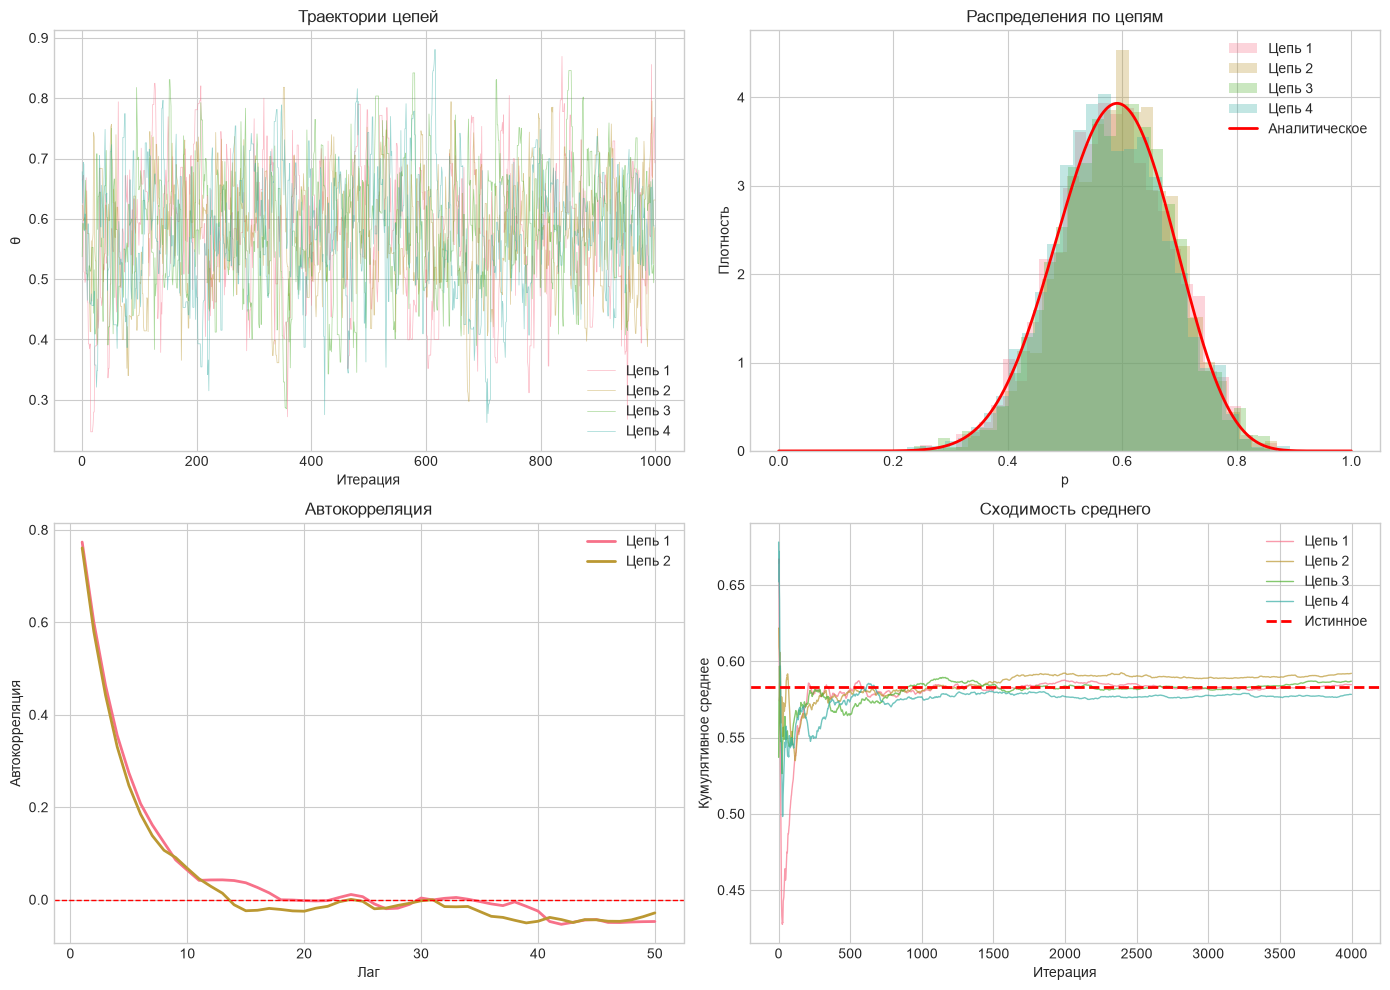

In [6]:
# Диагностика MCMC: Несколько цепей
np.random.seed(42)

# Запуск нескольких цепей
n_chains = 4
n_samples = 5000
chains = []

for i in range(n_chains):
    chain = metropolis_hastings(n_samples, proposal_std=0.1)
    chains.append(chain[burn_in:])  # Отбрасываем burn-in

chains = np.array(chains)

# R-hat
def compute_rhat(chains):
    """Вычисление R-hat статистики"""
    n_chains, n_samples = chains.shape
    
    # Средние по цепям
    chain_means = np.mean(chains, axis=1)
    overall_mean = np.mean(chain_means)
    
    # Дисперсия между цепями
    B = n_samples * np.var(chain_means, ddof=1)
    
    # Дисперсия внутри цепей
    W = np.mean([np.var(chain, ddof=1) for chain in chains])
    
    # R-hat
    var_plus = ((n_samples - 1) / n_samples) * W + B / n_samples
    rhat = np.sqrt(var_plus / W)
    
    return rhat

rhat = compute_rhat(chains)

print('Диагностика MCMC')
print('=' * 60)
print(f'Количество цепей: {n_chains}')
print(f'Количество сэмплов на цепь: {n_samples}')
print(f'R-hat: {rhat:.4f}')
print(f'Сошлись? {"Да" if abs(rhat - 1) < 0.1 else "Нет"}')

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Траектории всех цепей
for i, chain in enumerate(chains):
    axes[0, 0].plot(chain[:1000], alpha=0.5, linewidth=0.5, label=f'Цепь {i+1}')
axes[0, 0].set_xlabel('Итерация')
axes[0, 0].set_ylabel('θ')
axes[0, 0].set_title('Траектории цепей')
axes[0, 0].legend()

# Гистограммы
for i, chain in enumerate(chains):
    axes[0, 1].hist(chain, bins=30, density=True, alpha=0.3, label=f'Цепь {i+1}')
axes[0, 1].plot(p_range, analytical_posterior, 'r-', linewidth=2, label='Аналитическое')
axes[0, 1].set_xlabel('p')
axes[0, 1].set_ylabel('Плотность')
axes[0, 1].set_title('Распределения по цепям')
axes[0, 1].legend()

# Автокорреляция
for i, chain in enumerate(chains[:2]):
    autocorr = [np.corrcoef(chain[:-lag], chain[lag:])[0, 1] 
                for lag in range(1, 51)]
    axes[1, 0].plot(range(1, 51), autocorr, linewidth=2, label=f'Цепь {i+1}')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel('Лаг')
axes[1, 0].set_ylabel('Автокорреляция')
axes[1, 0].set_title('Автокорреляция')
axes[1, 0].legend()

# Cumulative mean
for i, chain in enumerate(chains):
    cummean = np.cumsum(chain) / np.arange(1, len(chain) + 1)
    axes[1, 1].plot(cummean, alpha=0.7, linewidth=1, label=f'Цепь {i+1}')
axes[1, 1].axhline(alpha_post/(alpha_post+beta_post), color='red', linestyle='--', 
                   linewidth=2, label='Истинное')
axes[1, 1].set_xlabel('Итерация')
axes[1, 1].set_ylabel('Кумулятивное среднее')
axes[1, 1].set_title('Сходимость среднего')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Упражнения

### Упражнение 1: Оценка числа π
1. Оцените π методом Монте-Карло с разным количеством точек (10², 10³, 10⁴, 10⁵)
2. Постройте график ошибки в зависимости от n
3. Какова скорость сходимости?

### Упражнение 2: Монте-Карло интегрирование
Вычислите интеграл $\int_0^1 e^{-x^2} dx$ методом Монте-Карло.
1. Сравните с точным значением (оно связано с функцией ошибок)
2. Оцените стандартную ошибку

### Упражнение 3: Цепь Маркова
Рассмотрите цепь Маркова с матрицей переходов:
$$P = \begin{pmatrix} 0.5 & 0.5 \\ 0.3 & 0.7 \end{pmatrix}$$

1. Найдите стационарное распределение
2. Симулируйте цепь длиной 10000 шагов
3. Сравните эмпирическое распределение с теоретическим

### Упражнение 4: MCMC
Используйте MCMC для байесовского вывода:
- Данные: 15 успехов из 25 испытаний
- Априорное: Beta(3, 3)

1. Запустите MCMC (алгоритм Метрополиса-Гастингса)
2. Проверьте R-hat для 4 цепей
3. Постройте 95% credible interval

---

**Решения** можно найти в ноутбуке `solutions/11_Solutions.ipynb`